In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from dotenv import load_dotenv
import os
import seaborn as sns
import epa_helpers as hlp
load_dotenv()

True

IMPORT THE DATA and PREP WORK

In [3]:
sales = pd.read_csv(os.getenv("CLEAN_DATA_PATH") + "/sales_train_cnt_0.csv")

In [ ]:
cat_cols = ["shop_id", "item_id", "item_category_id", "month_block_num"]
numeric_cols = ["item_price", "item_cnt_month"]
target_col = "item_cnt_month"

In [ ]:
sales = hlp.get_cat_columns(sales)

Basic Information

In [9]:
sales.shape

(2935843, 6)

In [40]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935843 entries, 0 to 2935842
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   item_price        float64
 1   item_cnt_month    float64
 2   shop_id           str    
 3   item_id           str    
 4   item_category_id  str    
 5   month_block_num   str    
dtypes: float64(2), str(4)
memory usage: 134.4 MB


SUMMARY STATISTICS

In [10]:
print("Summary for categorical variables")
sales[cat_cols].describe()

Summary for categorical variables


,shop_id,item_id,item_category_id,month_block_num
count,2935843,2935843,2935843,2935843
unique,60,21807,84,34
top,31,20949,40,11
freq,235636,31340,564651,143246


In [ ]:
print("Summary for numerical variables")
sales[numeric_cols].describe()

SUmmary for numerical variables


,item_price,item_cnt_month
count,2.935843e+06,2.935843e+06
mean,8.908535e+02,7.410409e+00
std,1.729801e+03,3.033649e+01
min,7.000000e-02,0.000000e+00
25%,2.490000e+02,1.000000e+00
50%,3.990000e+02,2.000000e+00
75%,9.990000e+02,5.000000e+00
max,3.079800e+05,2.253000e+03


CORRELATION MATRICES

In [ ]:
#correlation matrix of categorical variables
cat_corr_matrix = hlp.get_nominal_var_corr_matrix()

PLOTTING GRAPHS

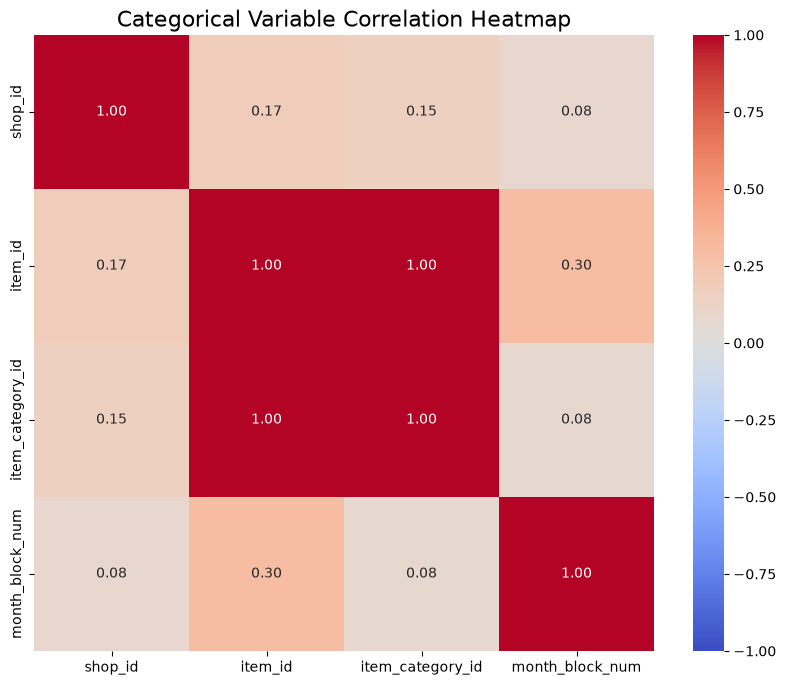

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(cat_corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Categorical Variable Correlation Heatmap", fontsize=16)
plt.show()

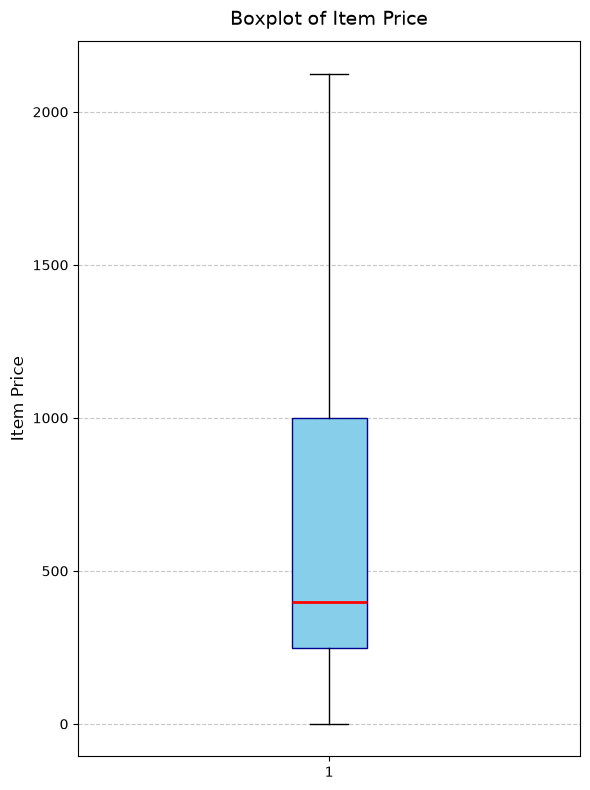

In [26]:
import matplotlib.pyplot as plt

# Create boxplot of item_price
plt.figure(figsize=(6, 8))
plt.boxplot(
    sales['item_price'],
    orientation='vertical',
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='darkblue'),
    medianprops=dict(color='red', linewidth=2),
    showfliers=False
)
plt.title('Boxplot of Item Price', fontsize=14, pad=12)
plt.ylabel('Item Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

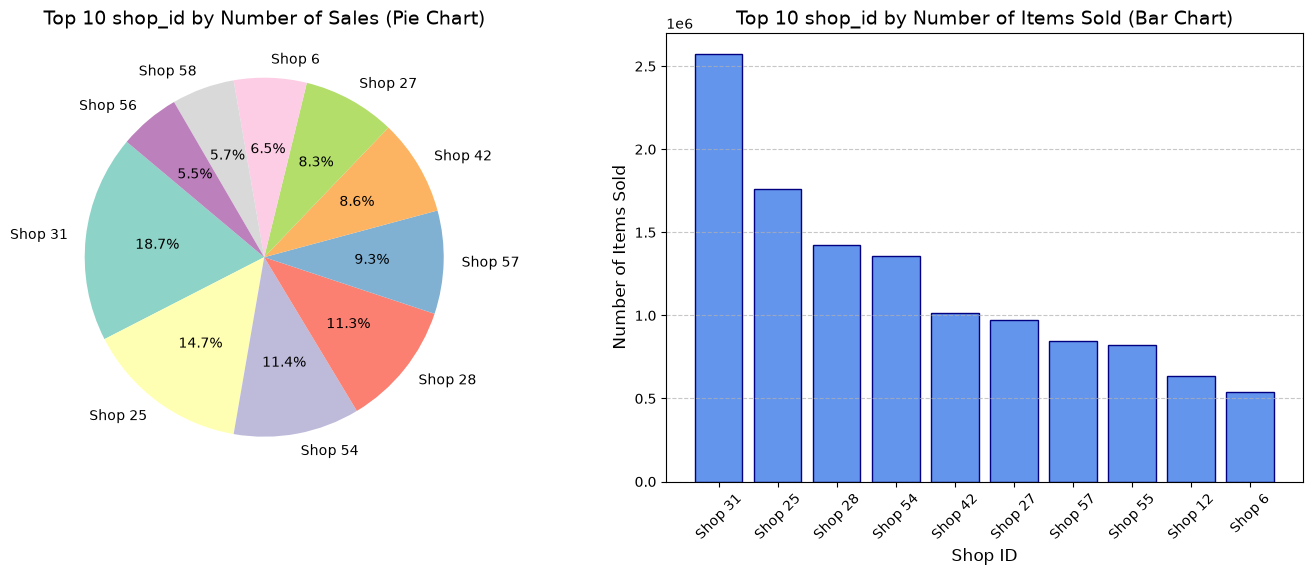

In [32]:
hlp.get_charts_for_cat_vars(sales, colname="shop_id")

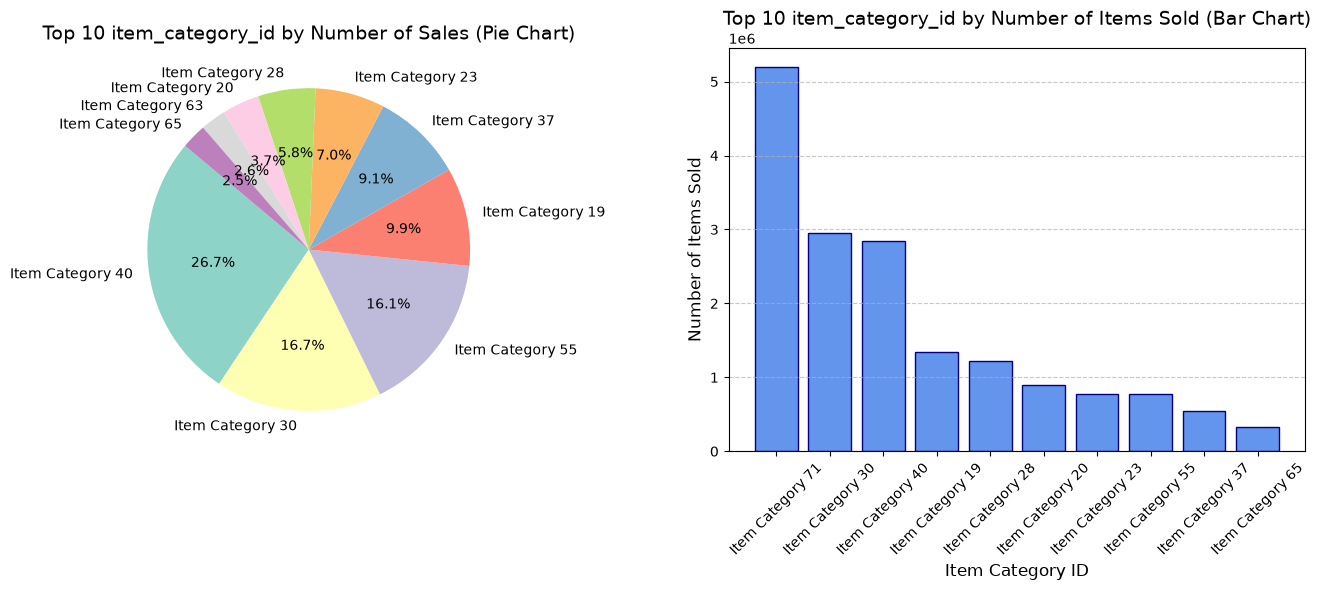

In [33]:
hlp.get_charts_for_cat_vars(sales, "item_category_id")